# Кейс 4. ROMI офлайн-ивентов без трекинга лидов

**Вопрос:** окупились ли 4 офлайн-ивента (ярмарки, стенды, промо) и стоит ли продолжать.

**Сложность:** у ивентов не было промокода, отдельной ссылки или QR с меткой. Пользователи, пришедшие с ивента, лежат в базе как organic. Прямо посчитать их нельзя.

**Метод:** инкрементальный прирост регистраций.
1. Берём дневные регистрации в городе ивента.
2. Окно ивента = дни ивента + 2 дня хвоста.
3. База = медиана дневных регистраций за 14 дней до и 14 дней после окна, без дней окна.
4. Прирост = регистрации в окне - база x число дней окна.
5. Инкрементальная выручка = прирост x ARPU обычной регистрации того же города (30 дней и всё время до выгрузки).
6. ROMI = (инкрементальная выручка - затраты) / затраты.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import pf

pf.setup_style()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
con = pf.connect()
q = pf.Q(con, "queries.sql")
events = con.sql("SELECT * FROM offline_events ORDER BY event_id").df()
events

,event_id,event_name,city,start_date,end_date,cost_usd
0,1,Ярмарка в ТРЦ,Almaty,2025-10-18,2025-10-19,6000
1,2,Стенд на фестивале,Astana,2026-02-21,2026-02-22,4500
2,3,Городской маркет,Almaty,2026-05-09,2026-05-11,8000
3,4,Промо в университете,Shymkent,2026-07-04,2026-07-04,3500


## 1. Регистрации вокруг ивентов

In [2]:
daily = q("daily_city")
daily["day"] = pd.to_datetime(daily["day"])
up = q("event_uplift")
up

,event_id,event_name,city,start_date,window_end,cost_usd,window_days,regs_window,baseline_per_day,baseline_days,uplift_regs
0,1,Ярмарка в ТРЦ,Almaty,2025-10-18,2025-10-21,6000,4,274.00,32.00,28,146.00
1,2,Стенд на фестивале,Astana,2026-02-21,2026-02-24,4500,4,166.00,23.00,28,74.00
2,3,Городской маркет,Almaty,2026-05-09,2026-05-13,8000,5,484.00,37.50,28,296.50
3,4,Промо в университете,Shymkent,2026-07-04,2026-07-06,3500,3,139.00,11.00,28,106.00


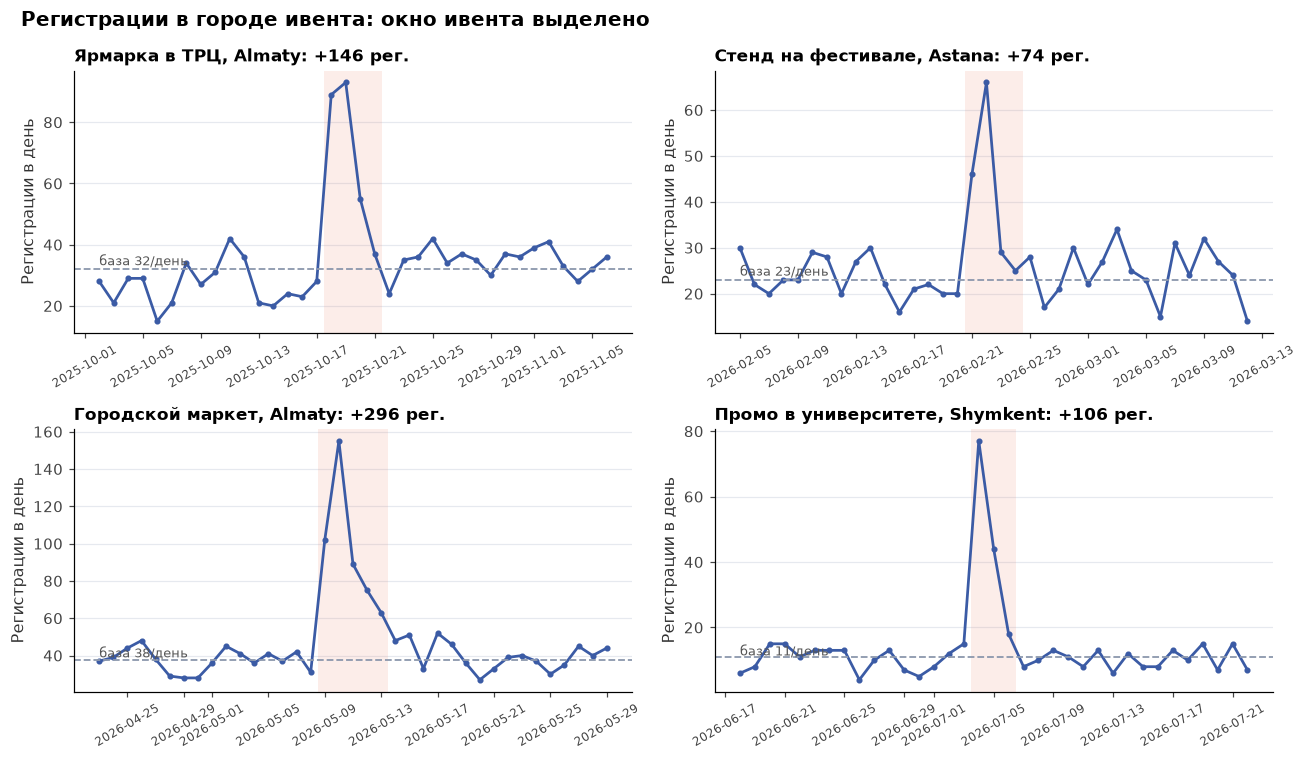

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
for ax, r in zip(axes.ravel(), up.itertuples()):
    s = daily[daily["city"] == r.city].set_index("day")["regs"]
    lo, hi = pd.Timestamp(r.start_date) - pd.Timedelta(days=16), pd.Timestamp(r.window_end) + pd.Timedelta(days=16)
    s = s.loc[lo:hi]
    ax.axvspan(pd.Timestamp(r.start_date) - pd.Timedelta(hours=12), pd.Timestamp(r.window_end) + pd.Timedelta(hours=12),
               color=pf.COLORS["accent"], alpha=0.12, lw=0)
    ax.plot(s.index, s.values, color=pf.COLORS["main"], lw=1.8, marker="o", ms=3)
    ax.axhline(r.baseline_per_day, color=pf.COLORS["muted"], ls="--", lw=1.2)
    ax.text(s.index[0], r.baseline_per_day * 1.04, f"база {r.baseline_per_day:.0f}/день", fontsize=8.5, color="#555555")
    ax.set_title(f"{r.event_name}, {r.city}: +{r.uplift_regs:.0f} рег.", fontsize=11)
    ax.set_ylabel("Регистрации в день")
    ax.tick_params(axis="x", labelsize=8, rotation=30)
fig.suptitle("Регистрации в городе ивента: окно ивента выделено", x=0.02, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
pf.save(fig, "01_events_daily")
plt.show()

## 2. Проверка на шум: плацебо-окна

Сдвигаем такое же окно на даты без ивентов (в тех же городах, 2025-06 - 2026-08, не ближе 20 дней к любому ивенту) и считаем "прирост" тем же методом. Если метод честный, у плацебо прирост около нуля, а у настоящих ивентов далеко за его разбросом.

In [4]:
def uplift_at(series: pd.Series, start: pd.Timestamp, days: int) -> float:
    end = start + pd.Timedelta(days=days - 1)
    around = series.loc[start - pd.Timedelta(days=14): end + pd.Timedelta(days=14)]
    base = around[(around.index < start) | (around.index > end)].median()
    return series.loc[start:end].sum() - base * days

rows = []
ev_days = [pd.Timestamp(d) for d in up["start_date"]]
for r in up.itertuples():
    s = daily[daily["city"] == r.city].set_index("day")["regs"].asfreq("D", fill_value=0)
    for start in pd.date_range("2025-06-01", "2026-08-15", freq="D"):
        if min(abs((start - e).days) for e in ev_days) <= 20:
            continue
        rows.append((r.event_id, start, uplift_at(s, start, r.window_days)))
placebo = pd.DataFrame(rows, columns=["event_id", "start", "uplift"])
pl = placebo.groupby("event_id")["uplift"].agg(p05=lambda x: x.quantile(0.05), median="median",
                                               p95=lambda x: x.quantile(0.95), sd="std")
pl = pl.join(up.set_index("event_id")["uplift_regs"])
pl["share_placebo_above"] = [(placebo.loc[placebo.event_id == i, "uplift"] >= u).mean() for i, u in pl["uplift_regs"].items()]
pl

,p05,median,p95,sd,uplift_regs,share_placebo_above
event_id,,,,,,
1,-20.20,0.00,21.20,12.76,146.00,0.00
2,-14.20,0.00,19.00,10.14,74.00,0.00
3,-23.00,0.00,22.10,13.92,296.50,0.00
4,-9.00,1.00,11.00,6.29,106.00,0.00


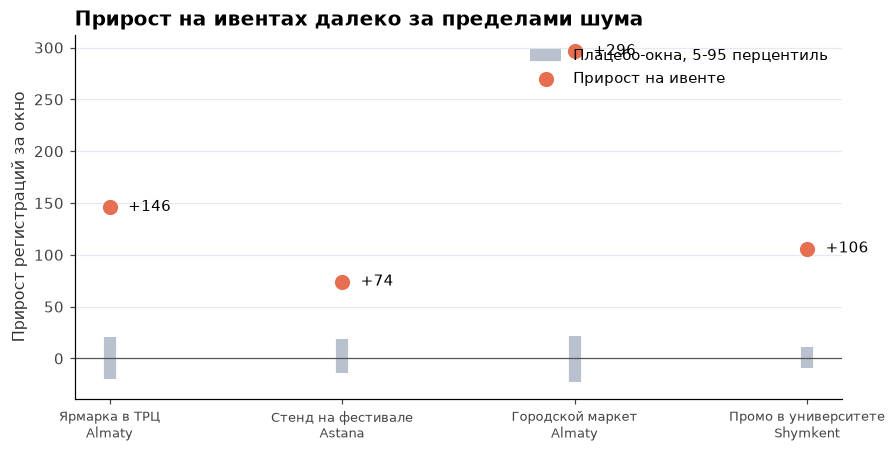

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.3))
x = np.arange(len(pl))
ax.vlines(x, pl["p05"], pl["p95"], color=pf.COLORS["muted"], lw=8, alpha=0.6, label="Плацебо-окна, 5-95 перцентиль")
ax.scatter(x, pl["uplift_regs"], color=pf.COLORS["accent"], s=80, zorder=3, label="Прирост на ивенте")
for i, v in enumerate(pl["uplift_regs"]):
    ax.text(i + 0.08, v, f"+{v:.0f}", va="center", fontsize=9.5)
ax.axhline(0, color="#555555", lw=0.8)
ax.set_xticks(x, [f"{n}\n{c}" for n, c in zip(up["event_name"], up["city"])], fontsize=8.5)
ax.set_ylabel("Прирост регистраций за окно")
ax.set_title("Прирост на ивентах далеко за пределами шума")
ax.legend(loc="upper right")
pf.save(fig, "02_placebo")
plt.show()

## 3. Инкрементальная выручка и ROMI

In [6]:
arpu = q("baseline_arpu")
cpr_paid = q("paid_cpr")
paid_cpr = cpr_paid.loc[0, "cpr"]
t = up.merge(arpu, on="event_id")
t["inc_rev_30"] = t["uplift_regs"] * t["arpu_30"]
t["inc_rev_life"] = t["uplift_regs"] * t["arpu_lifetime"]
t["romi_30"] = t["inc_rev_30"] / t["cost_usd"] - 1
t["romi_life"] = t["inc_rev_life"] / t["cost_usd"] - 1
t["cpr_incremental"] = t["cost_usd"] / t["uplift_regs"]
t["days_since_event"] = (pd.Timestamp("2026-09-14") - pd.to_datetime(t["start_date"])).dt.days
t[["event_name", "city", "cost_usd", "uplift_regs", "base_users", "arpu_30", "arpu_lifetime", "days_since_event",
   "inc_rev_30", "inc_rev_life", "romi_30", "romi_life", "cpr_incremental"]]

,event_name,city,cost_usd,uplift_regs,base_users,arpu_30,arpu_lifetime,days_since_event,inc_rev_30,inc_rev_life,romi_30,romi_life,cpr_incremental
0,Ярмарка в ТРЦ,Almaty,6000,146.00,867,3.70,7.71,331,539.89,"1,126.05",-0.91,-0.81,41.10
1,Стенд на фестивале,Astana,4500,74.00,677,3.06,5.53,205,226.75,408.85,-0.95,-0.91,60.81
2,Городской маркет,Almaty,8000,296.50,1076,3.61,5.81,128,"1,070.54","1,723.44",-0.87,-0.78,26.98
3,Промо в университете,Shymkent,3500,106.00,296,3.79,6.43,72,401.64,682.03,-0.89,-0.81,33.02


In [7]:
tot_cost = t["cost_usd"].sum()
tot_uplift = t["uplift_regs"].sum()
romi_30_total = t["inc_rev_30"].sum() / tot_cost - 1
romi_life_total = t["inc_rev_life"].sum() / tot_cost - 1
cpr_total = tot_cost / tot_uplift
print(f"4 ивента: затраты ${tot_cost:,.0f}, прирост {tot_uplift:,.0f} регистраций")
print(f"Цена инкрементальной регистрации ${cpr_total:.1f} против ${paid_cpr:.2f} в платном таргете ({cpr_total / paid_cpr:.0f}x)")
print(f"ROMI 30 дней {romi_30_total:.0%}, ROMI за всё время до выгрузки {romi_life_total:.0%}")

4 ивента: затраты $22,000, прирост 622 регистраций
Цена инкрементальной регистрации $35.3 против $2.98 в платном таргете (12x)
ROMI 30 дней -90%, ROMI за всё время до выгрузки -82%


Даже если ARPU пришедших с ивента такой же, как у обычной регистрации (скорее всего он ниже: люди регистрируются ради подарка на стенде), выручка покрывает малую часть затрат. Сколько регистраций нужно было для выхода в ноль по выручке:

In [8]:
be = t["cost_usd"] / t["arpu_lifetime"]
t["breakeven_regs"] = be
t["breakeven_multiple"] = be / t["uplift_regs"]
t["revenue_covers"] = t["inc_rev_life"] / t["cost_usd"]
print(f"Выручка покрывает {t['revenue_covers'].min():.0%}-{t['revenue_covers'].max():.0%} затрат, "
      f"для выхода в ноль прирост нужен в {t['breakeven_multiple'].min():.0f}-{t['breakeven_multiple'].max():.0f} раз больше")
t[["event_name", "uplift_regs", "breakeven_regs", "breakeven_multiple", "revenue_covers"]]

Выручка покрывает 9%-22% затрат, для выхода в ноль прирост нужен в 5-11 раз больше


,event_name,uplift_regs,breakeven_regs,breakeven_multiple,revenue_covers
0,Ярмарка в ТРЦ,146.00,777.94,5.33,0.19
1,Стенд на фестивале,74.00,814.48,11.01,0.09
2,Городской маркет,296.50,"1,376.32",4.64,0.22
3,Промо в университете,106.00,543.96,5.13,0.19


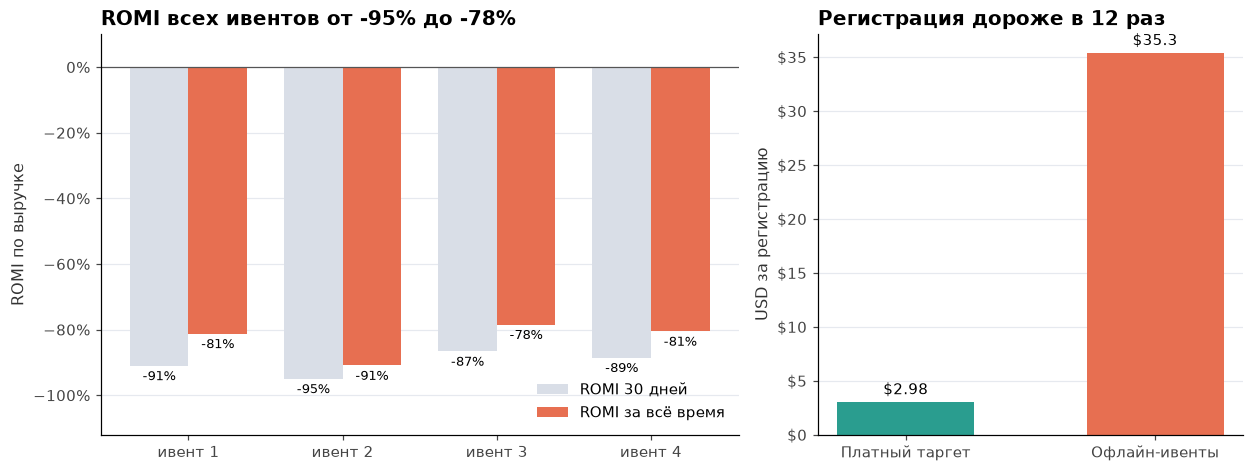

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
x = np.arange(len(t))
w = 0.38
b1 = ax.bar(x - w / 2, t["romi_30"], w, color=pf.COLORS["light"], label="ROMI 30 дней")
b2 = ax.bar(x + w / 2, t["romi_life"], w, color=pf.COLORS["accent"], label="ROMI за всё время")
ax.bar_label(b1, labels=[f"{v:.0%}" for v in t["romi_30"]], padding=3, fontsize=8.5)
ax.bar_label(b2, labels=[f"{v:.0%}" for v in t["romi_life"]], padding=3, fontsize=8.5)
ax.axhline(0, color="#555555", lw=0.8)
ax.set_ylim(-1.12, 0.1)
pf.pct_axis(ax)
ax.set_xticks(x, [f"ивент {i}" for i in t["event_id"]])
ax.set_ylabel("ROMI по выручке")
ax.set_title(f"ROMI всех ивентов от {t['romi_30'].min():.0%} до {t['romi_life'].max():.0%}")
ax.legend(loc="lower right")
ax = axes[1]
bars = ax.bar(["Платный таргет", "Офлайн-ивенты"], [paid_cpr, cpr_total], color=[pf.COLORS["ok"], pf.COLORS["accent"]], width=0.55)
ax.bar_label(bars, labels=[f"${paid_cpr:.2f}", f"${cpr_total:.1f}"], padding=3)
pf.usd_axis(ax)
ax.set_ylabel("USD за регистрацию")
ax.set_title(f"Регистрация дороже в {cpr_total / paid_cpr:.0f} раз")
fig.tight_layout()
pf.save(fig, "03_romi_cpr")
plt.show()

## 4. Почему "выручка x доля в бюджете" не измерение

Альтернатива, которую предлагали: взять выручку месяца и умножить на долю ивента в маркетинговом бюджете месяца. Такой расчёт вообще не смотрит на результат ивента: он распределяет выручку пропорционально затратам. Чем больше потратили, тем больше "заработали".

In [10]:
bs = q("budget_share")
bs

,event_id,event_name,cost_usd,budget_total,budget_share,month_revenue,attributed_revenue,romi_budget_share
0,1,Ярмарка в ТРЦ,6000,"16,600.94",0.36,"20,724.67","7,490.42",0.25
1,2,Стенд на фестивале,4500,"15,778.83",0.29,"22,340.29","6,371.28",0.42
2,3,Городской маркет,8000,"19,496.13",0.41,"27,932.02","11,461.56",0.43
3,4,Промо в университете,3500,"15,785.58",0.22,"29,906.72","6,630.96",0.89


In [11]:
# Проверка: тот же "метод" для ивента, который не дал ни одной регистрации.
# Подставляем вымышленный ивент 4-го числа месяца без ивентов с тем же бюджетом.
fake = con.sql("""
    SELECT SUM(price) FILTER (WHERE payment_status = 2) AS revenue
    FROM orders
    WHERE created_at >= DATE '2026-03-01' AND created_at < DATE '2026-04-01'
""").df().loc[0, "revenue"]
paid_march = con.sql("SELECT amount_usd FROM marketing_budget WHERE month = DATE '2026-03-01' AND item = 'paid_digital'").df().iloc[0, 0]
fake_cost = 5000
fake_romi = fake * fake_cost / (paid_march + fake_cost) / fake_cost - 1
s_mar = daily[daily["city"] == "Almaty"].set_index("day")["regs"].asfreq("D", fill_value=0)
fake_uplift = uplift_at(s_mar, pd.Timestamp("2026-03-14"), 4)
print(f"Вымышленный ивент в марте 2026 за $5,000: прирост регистраций {fake_uplift:+.0f}, ROMI по доле бюджета {fake_romi:+.0%}")

Вымышленный ивент в марте 2026 за $5,000: прирост регистраций +0, ROMI по доле бюджета +56%


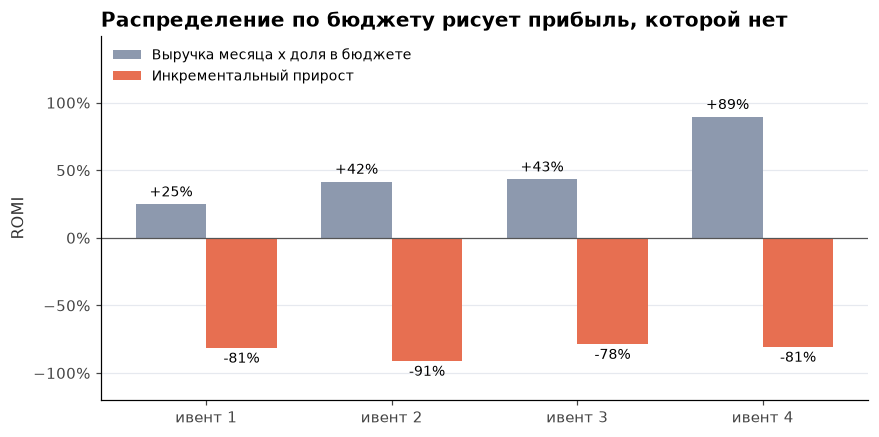

In [12]:
cmpm = pd.DataFrame({
    "Доля бюджета": bs.set_index("event_id")["romi_budget_share"],
    "Прирост, всё время": t.set_index("event_id")["romi_life"],
})
fig, ax = plt.subplots(figsize=(9, 4.3))
x = np.arange(len(cmpm))
w = 0.38
b1 = ax.bar(x - w / 2, cmpm["Доля бюджета"], w, color=pf.COLORS["muted"], label="Выручка месяца x доля в бюджете")
b2 = ax.bar(x + w / 2, cmpm["Прирост, всё время"], w, color=pf.COLORS["accent"], label="Инкрементальный прирост")
ax.bar_label(b1, labels=[f"{v:+.0%}" for v in cmpm.iloc[:, 0]], padding=3, fontsize=9)
ax.bar_label(b2, labels=[f"{v:+.0%}" for v in cmpm.iloc[:, 1]], padding=3, fontsize=9)
ax.axhline(0, color="#555555", lw=0.8)
pf.pct_axis(ax)
ax.set_xticks(x, [f"ивент {i}" for i in cmpm.index])
ax.set_ylabel("ROMI")
ax.set_ylim(-1.2, cmpm.values.max() + 0.6)
ax.set_title("Распределение по бюджету рисует прибыль, которой нет")
ax.legend(loc="upper left", fontsize=9)
pf.save(fig, "04_budget_share_vs_uplift")
plt.show()

## 5. Ограничения

- Медиана по соседним дням не учитывает день недели. Ивенты проходили в выходные, когда регистраций и так примерно на 15% больше, поэтому прирост скорее завышен.
- ARPU взят у обычных регистраций. У пришедших на стенд за подарком ARPU обычно ниже, это ещё сильнее снижает ROMI.
- ROMI посчитан по выручке, а не по марже. По марже результат хуже.
- Эффект узнаваемости бренда в долгую метод не ловит. Если он есть, его надо мерить отдельно (опрос, брендовый поиск), а не приписывать ивенту выручку месяца.

Все допущения работают в пользу ивентов, и ROMI всё равно глубоко отрицательный.

In [13]:
res = {
    "total_cost": tot_cost,
    "total_uplift": tot_uplift,
    "cpr_incremental": cpr_total,
    "paid_cpr": paid_cpr,
    "cpr_ratio": cpr_total / paid_cpr,
    "romi_30_total": romi_30_total,
    "romi_life_total": romi_life_total,
    "romi_life_min": t["romi_life"].min(),
    "romi_life_max": t["romi_life"].max(),
    "romi_30_min": t["romi_30"].min(),
    "romi_30_max": t["romi_30"].max(),
    "breakeven_multiple_min": t["breakeven_multiple"].min(),
    "breakeven_multiple_max": t["breakeven_multiple"].max(),
    "revenue_covers_min": t["revenue_covers"].min(),
    "revenue_covers_max": t["revenue_covers"].max(),
    "budget_share_romi_min": bs["romi_budget_share"].min(),
    "budget_share_romi_max": bs["romi_budget_share"].max(),
    "fake_event_uplift": fake_uplift,
    "fake_event_romi": fake_romi,
    "placebo_max_share_above": pl["share_placebo_above"].max(),
}
for r in t.itertuples():
    res[f"event{r.event_id}_uplift"] = r.uplift_regs
    res[f"event{r.event_id}_cost"] = r.cost_usd
    res[f"event{r.event_id}_romi_life"] = r.romi_life
    res[f"event{r.event_id}_cpr"] = r.cpr_incremental
pf.save_results(res)
pd.Series(res)

total_cost                22,000.00
total_uplift                 622.50
cpr_incremental               35.34
paid_cpr                       2.98
cpr_ratio                     11.85
romi_30_total                 -0.90
romi_life_total               -0.82
romi_life_min                 -0.91
romi_life_max                 -0.78
romi_30_min                   -0.95
romi_30_max                   -0.87
breakeven_multiple_min         4.64
breakeven_multiple_max        11.01
revenue_covers_min             0.09
revenue_covers_max             0.22
budget_share_romi_min          0.25
budget_share_romi_max          0.89
fake_event_uplift              0.00
fake_event_romi                0.56
placebo_max_share_above        0.00
event1_uplift                146.00
event1_cost                6,000.00
event1_romi_life              -0.81
event1_cpr                    41.10
event2_uplift                 74.00
event2_cost                4,500.00
event2_romi_life              -0.91
event2_cpr                  